# PCA POKEMON

#### Objetivo


Existen casos en que las variables no se pueden representar visualmente debido a que necesitaríamos varias
dimensiones para ello. Para evitar esto, existe una metodología la cual, un set de datos multidimensional,
podemos transformarlo para poder explicar gran parte de la información en 2 o 3 dimensiones. Dicha
metodología se conoce con el nombre de Principal Component Analysis (PCA). Vamos a aplicarlo a un set de
datos que está colgado en Canvas y vamos a dar una serie de explicaciones de que ocurre.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

1.- (0,5 puntos) Lo primero que habrá que hacer será estandarizar los datos para que las diferencias de rango
no supongan un problema a la hora de procesar la información. Usa para ello el método StandardScaler de la
librería scikitk-learn.

In [4]:
# Cargar el archivo CSV
def load_data(file_path):
    return pd.read_csv(file_path)

# Función para estandarizar los datos
def standardize_data(df, numeric_columns):
    scaler = StandardScaler()
    df_scaled = df.copy()
    df_scaled[numeric_columns] = scaler.fit_transform(df[numeric_columns])
    return df_scaled

# Guardar los datos estandarizados en un nuevo archivo CSV
def save_data(df, output_file):
    df.to_csv(output_file, index=False)
    print(f"Datos guardados en {output_file}")

# Ruta del archivo CSV de entrada y salida
file_path = "Practica 1-3 Pokemon.csv"
output_file = "Pokemon_Estandarizado.csv"

# Cargar datos
df = load_data(file_path)

# Seleccionar las columnas numéricas a estandarizar
numeric_columns = ["PS", "Ataque", "Defensa", "Ataque especial", "Defensa especial", "Velocidad"]

# Aplicar estandarización
df_scaled = standardize_data(df, numeric_columns)

# Guardar el nuevo DataFrame estandarizado
save_data(df_scaled, output_file)

# Mostrar las primeras filas del DataFrame estandarizado
print(df_scaled.head())


Datos guardados en Pokemon_Estandarizado.csv
      Pokémon   Tipo        PS    Ataque  Defensa  Ataque especial  \
0  TYPHLOSION  Fuego -0.326164  0.054313    -0.75         0.564152   
1      PONYTA  Fuego -0.326164  0.054313    -0.75        -1.171700   
2     TORKOAL  Fuego -0.326164  0.054313     1.75        -0.303774   
3    ARCANINE  Fuego  0.978492  2.226814     0.50         0.564152   
4     STARMIE   Agua -0.326164  0.054313     0.50         0.564152   

   Defensa especial  Velocidad  
0             -0.50   1.037975  
1             -0.50   0.135388  
2             -0.50  -1.669787  
3              0.75   1.037975  
4             -0.50   1.037975  


2.- (2 puntos) El segundo paso será a partir de los datos anteriores, obtener los autovalores (eigenvalues) y los
autovectores (eigenvectors) que nos permitan explicar cuántos componentes necesitamos para representar
los datos iniciales. Para ello primer habrá que obtener la matriz de covarianza mediante el método cov de
numpy y después aplicarle a dicha matriz el método linalg.eig también de numpy. Obten un DataFrame con el
porcentaje de varianza y el acumulado por cada componente. Explica que quieren decir estos datos.

In [ ]:
# Calcular la matriz de covarianza
cov_matrix = np.cov(df_scaled[numeric_columns].T)

# Obtener los autovalores y autovectores
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Calcular el porcentaje de varianza explicada por cada componente
variance_explained = eigenvalues / np.sum(eigenvalues)

# Calcular el acumulado de varianza explicada
cumulative_variance_explained = np.cumsum(variance_explained)

# Crear un DataFrame con los resultados
df_variance = pd.DataFrame({
    'Autovalores': eigenvalues,
    'Porcentaje de Varianza Explicada': variance_explained,
    'Varianza Acumulada': cumulative_variance_explained
})

print(df_variance)

   Autovalores  Porcentaje de Varianza Explicada  Varianza Acumulada
0     2.629979                          0.416413            0.416413
1     1.550661                          0.245521            0.661935
2     0.164206                          0.025999            0.687934
3     0.474598                          0.075145            0.763079
4     0.715521                          0.113291            0.876370
5     0.780824                          0.123630            1.000000


Aquí, la Componente 1 tiene el autovalor más alto (2.629979), lo que significa que es la que más información conserva.La Componente 1 explica el 41.64% de la varianza total y la Componente 2 el 24.55%, lo que significa que con solo estas dos componentes ya se puede representar el 66.19% de la información original.Las demás componentes tienen menor influencia, lo que sugiere que se pueden descartar si queremos reducir la dimensionalidad.Las últimas componentes tienen valores pequeños (menor del 10%), lo que indica que aportan poca información nueva y podrían ser descartadas.

Si se quisiera representar los datos con el menor número de dimensiones sin perder mucha información, lo más eficiente sería utilizar las dos o tres primeras componentes.
En resumen, las dos primeras componentes ya capturan la mayor parte de la estructura de los datos, lo que justifica su uso en la visualización en 2D del PCA.

3.- (1,5 puntos) Por último queremos representar gráficamente los individuos de nuestro dataset pero usando
los valores de los componentes principales obtenidas. Obtén un diagrama de dispersión en 2 dimensiones y
comenta que has interpretado en él.

In [14]:
# Cargar el archivo CSV estandarizado
def load_data(file_path):
    return pd.read_csv(file_path)

# Calcular la matriz de covarianza y obtener componentes principales
def compute_pca(df, numeric_columns):
    cov_matrix = np.cov(df[numeric_columns].T)
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    component_table = pd.DataFrame(
        eigenvectors[:, :2],  # Solo las dos primeras componentes
        index=numeric_columns,
        columns=["Componente 1", "Componente 2"]
    )
    return component_table

# Ruta del archivo CSV estandarizado
file_path = "Pokemon_Estandarizado.csv"

# Cargar datos
df_estandarizado = load_data(file_path)

# Seleccionar columnas numéricas
numeric_columns = ["PS", "Ataque", "Defensa", "Ataque especial", "Defensa especial", "Velocidad"]

# Obtener la tabla de componentes principales
df_components = compute_pca(df_estandarizado, numeric_columns)

# Mostrar resultados
print(df_components)

                  Componente 1  Componente 2
PS                    0.454541      0.158473
Ataque                0.450729     -0.251981
Defensa               0.318823     -0.632008
Ataque especial       0.423317      0.382280
Defensa especial      0.480989     -0.168522
Velocidad             0.279357      0.580880


Cada componente principal es una combinación lineal de las variables originales. Los valores en la tabla indican qué tanto influye cada variable en cada componente.

Valores positivos altos → Indican que la variable contribuye fuertemente en esa dirección.
Valores negativos altos → Indican que la variable contribuye en la dirección opuesta.


**Componente 1:**
Cogemos los valores positivos más altos, en este caso en función al output que hemos generado, son: PS (0.4545), Ataque (0.4507) y Defensa Especial (0.4809) y también podríamos añadir Ataque Especial (0.4233).

**Componente 2:** Cogemos los valores negativos más altos, en este caso: Defensa (-0.6320) y Velocidad (0.5800)

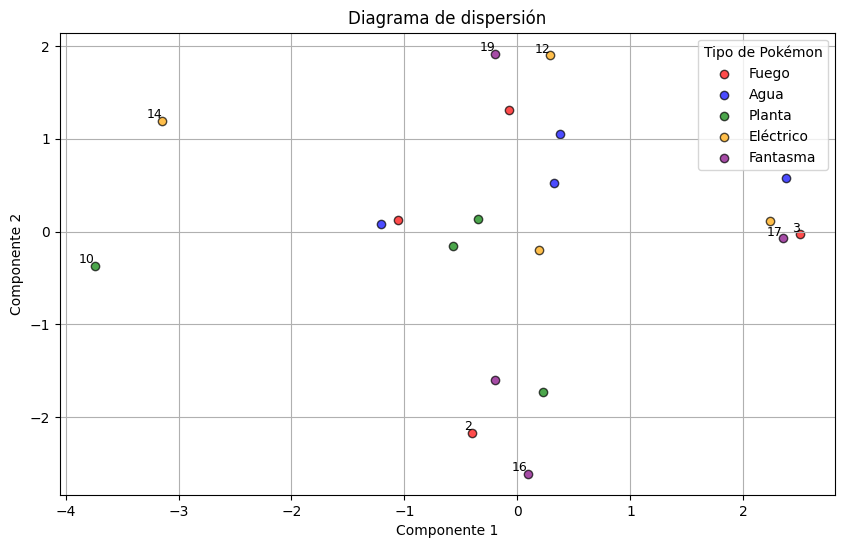

In [21]:
# Definir colores específicos para los tipos presentes en el dataset
color_dict = {
    'Fuego': 'red',
    'Agua': 'blue',
    'Planta': 'green',
    'Eléctrico': 'orange',
    'Fantasma': 'purple'
}

# Proyectar los datos originales en los componentes principales
projected_data = np.dot(df_scaled[numeric_columns], eigenvectors[:, :2])
df_projected = pd.DataFrame(projected_data, columns=['Componente 1', 'Componente 2'])
df_projected['Tipo'] = df['Tipo']
df_projected['Número'] = df.index  # Agregar el número del Pokémon

# Asignar colores a cada punto según su tipo
df_projected['Color'] = df_projected['Tipo'].map(color_dict)

# Crear el diagrama de dispersión con los colores definidos
plt.figure(figsize=(10, 6))
for tipo in color_dict.keys():
    subset = df_projected[df_projected['Tipo'] == tipo]
    plt.scatter(subset['Componente 1'], subset['Componente 2'], 
                label=tipo, color=color_dict[tipo], alpha=0.7, edgecolors='k')
    
    # Añadir etiquetas solo a los Pokémon seleccionados
    for i, row in subset.iterrows():
        if row['Número'] in [12, 19, 2, 16, 14, 10, 3, 17]:
            plt.text(row['Componente 1'], row['Componente 2'], str(row['Número']), fontsize=9, ha='right', va='bottom')

# Añadir etiquetas y título
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Diagrama de dispersión')

# Crear la leyenda
plt.legend(title="Tipo de Pokémon", loc="best")
plt.grid(True)
plt.show()

Los Pokémon situados en la parte superior derecha del gráfico, como los números **12(Jolteon) y 19(Gengar)**, destacan por su alto ataque, defensa especial y velocidad. Son ofensivos y rápidos, aunque no necesariamente tienen una gran capacidad defensiva. Su posición indica un equilibrio entre poder y agilidad.



En la parte inferior izquierda, los Pokémon **2(Torkoal) y 16(Dusknoir)** presentan valores bajos en ambas componentes principales. Esto sugiere que poseen una alta defensa, pero carecen de velocidad y capacidad ofensiva. Son Pokémon diseñados para resistir más tiempo en combate, aunque su baja movilidad puede ser una desventaja.



Los Pokémon en la parte superior izquierda, como los números **14(Pikachu) y 10(Cherubi)**, tienen una combinación de alta velocidad y ataque especial, pero una defensa más débil. Esto los convierte en atacantes eficaces en combate, aunque son vulnerables a golpes físicos debido a su menor resistencia.


Por otro lado, los Pokémon ubicados en la parte inferior derecha, como los números **3(Arcanine) y 17(Jiratina)**, combinan una ofensiva fuerte con una gran resistencia, pero sacrifican velocidad y ataque especial. Esto sugiere que son Pokémon robustos en combates físicos, aunque más lentos en su ejecución de ataques.